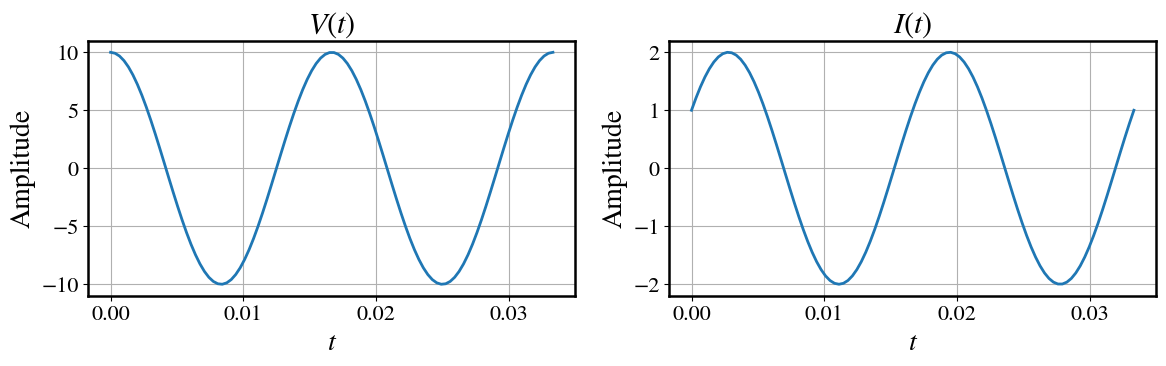

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Estilo tipográfico
# -----------------------------
mpl.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.8,
})

# -----------------------------
# Parâmetros
# -----------------------------
Vm = 10
Im = 2
omega = 2 * np.pi * 60
phi = np.pi / 3

T=2*np.pi/omega

t = np.linspace(0, 2*T, 100)

# -----------------------------
# Sinais
# -----------------------------
V_t = Vm * np.cos(omega * t)
I_t = Im * np.cos(omega * t - phi)

# -----------------------------
# Subplots lado a lado
# -----------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Tensão
axs[0].plot(t, V_t, linewidth=2)
axs[0].set_title(r"$V(t)$")
axs[0].set_xlabel(r"$t$")
axs[0].set_ylabel(r"Amplitude")
axs[0].grid(True)

# Corrente
axs[1].plot(t, I_t, linewidth=2)
axs[1].set_title(r"$I(t)$")
axs[1].set_xlabel(r"$t$")
axs[1].set_ylabel(r"Amplitude")
axs[1].grid(True)

# Ajuste de layout
plt.tight_layout()

# -----------------------------
# Salvar em PDF (vetorial)
# -----------------------------
plt.savefig("sinais_vi.pdf", format="pdf", bbox_inches="tight")

# Mostrar
plt.show()

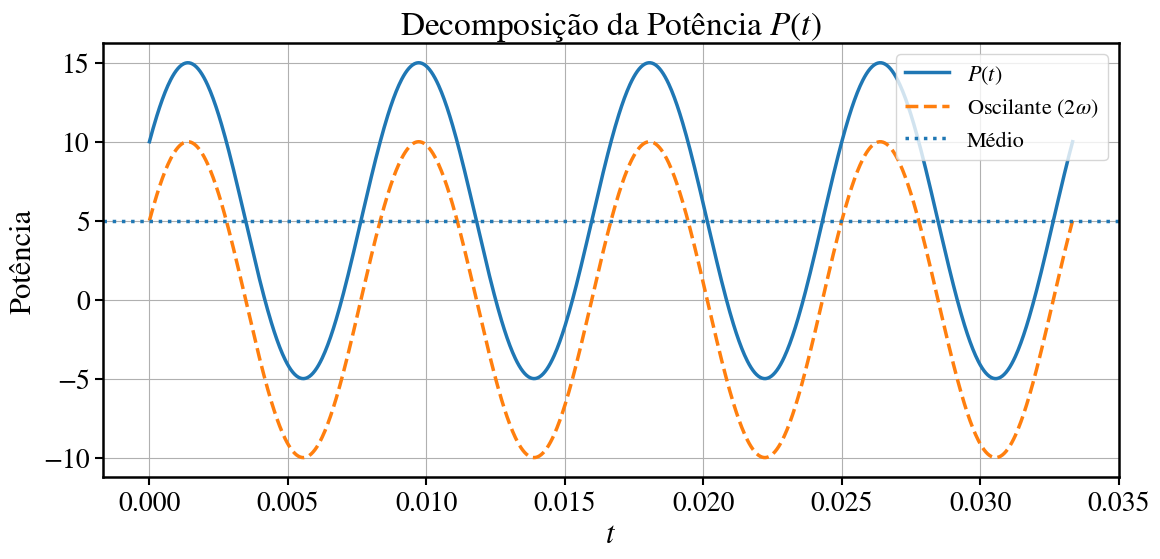

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Estilo tipográfico (equilibrado)
# -----------------------------
mpl.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.8,
})

# -----------------------------
# Parâmetros
# -----------------------------
Vm = 10
Im = 2
omega = 2 * np.pi * 60
phi = np.pi / 3

T = 2 * np.pi / omega
t = np.linspace(0, 2*T, 1000)

# -----------------------------
# Sinais
# -----------------------------
V_t = Vm * np.cos(omega * t)
I_t = Im * np.cos(omega * t - phi)

# Potência total
P_t = V_t * I_t

# Decomposição analítica
P_const = (Vm * Im / 2) * np.cos(phi)
P_osc = (Vm * Im / 2) * np.cos(2 * omega * t - phi)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# Potência total
ax.plot(t, P_t, linewidth=2.5, label=r"$P(t)$")

# Termo oscilante (2ω)
ax.plot(t, P_osc, linestyle="--", linewidth=2.5,
        label=r"Oscilante ($2\omega$)")

# Termo constante (linha horizontal)
ax.axhline(P_const, linestyle=":", linewidth=2.5,
           label=r"Médio")

# -----------------------------
# Ajustes finos (ticks e estética)
# -----------------------------
ax.tick_params(axis='both', which='major', width=1.5, length=6)

ax.set_title(r"Decomposição da Potência $P(t)$")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"Potência")
ax.grid(True)

ax.legend()

plt.tight_layout()

# -----------------------------
# Salvar em PDF vetorial
# -----------------------------
plt.savefig("potencia_decomposta.pdf", format="pdf", bbox_inches="tight")

# Mostrar
plt.show()

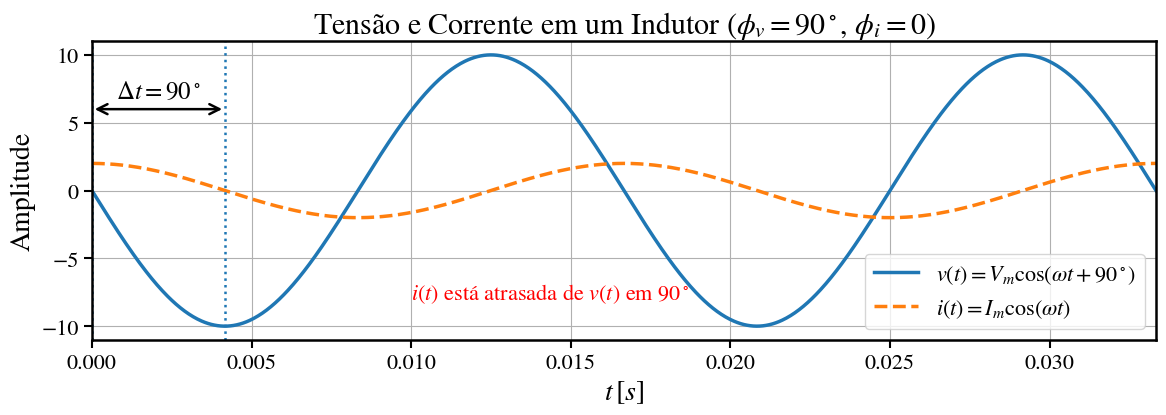

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# -----------------------------
# Estilo tipográfico
# -----------------------------
mpl.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.8,
})

# -----------------------------
# Parâmetros
# -----------------------------
Vm = 10
Im = 2
omega = 2 * np.pi * 60

T = 2 * np.pi / omega
t = np.linspace(0, 2*T, 1000)

# -----------------------------
# Sinais (caso correto do indutor)
# -----------------------------
I_t = Im * np.cos(omega * t)                  # fase 0
V_t = Vm * np.cos(omega * t + np.pi/2)        # fase +90°

# -----------------------------
# Instantes de referência
# -----------------------------
t_imax = 0.0              # máximo da corrente
t_vmax = 0.0              # vamos usar o cruzamento da corrente

# Melhor ponto para mostrar defasagem:
t_i_zero = np.pi/(2*omega)   # corrente cruza zero
t_v_max = np.pi/(2*omega)    # tensão está máxima aqui

# -----------------------------
# Figura
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 4.5))

# Sinais
ax.plot(t, V_t, linewidth=2.5, label=r"$v(t)=V_m\cos(\omega t + 90^\circ)$")
ax.plot(t, I_t, linewidth=2.5, linestyle="--",
        label=r"$i(t)=I_m\cos(\omega t)$")

# -----------------------------
# Marcação da defasagem
# -----------------------------
# dois máximos equivalentes:
t_v_peak = 0.0
t_i_peak = T/4   # corrente atinge máximo depois

ax.axvline(t_v_peak, linestyle=":", linewidth=1.8)
ax.axvline(t_i_peak, linestyle=":", linewidth=1.8)

# seta de defasagem
y_arrow = 6
ax.annotate(
    "",
    xy=(t_i_peak, y_arrow),
    xytext=(t_v_peak, y_arrow),
    arrowprops=dict(arrowstyle="<->", lw=1.8)
)

ax.text(
    (t_v_peak + t_i_peak)/2,
    y_arrow + 0.8,
    r"$\Delta t = 90^\circ$",
    ha="center"
)

# texto explicativo
ax.text(
    T*0.6,
    -8,
    r"$i(t)$ está atrasada de $v(t)$ em $90^\circ$",
    fontsize=16,
    color="red"
)

# -----------------------------
# Ajustes
# -----------------------------
ax.set_title(r"Tensão e Corrente em um Indutor ($\phi_v=90^\circ$, $\phi_i=0$)")
ax.set_xlabel(r"$t \, [s]$")
ax.set_ylabel(r"Amplitude")
ax.set_xlim(0, 2*T)
ax.grid(True)
ax.legend()

ax.tick_params(axis='both', which='major', width=1.5, length=6)

plt.tight_layout()

# -----------------------------
# Salvar
# -----------------------------
plt.savefig("indutor_fase_90.pdf", format="pdf", bbox_inches="tight")

plt.show()